## Extended Data Fig. 6a

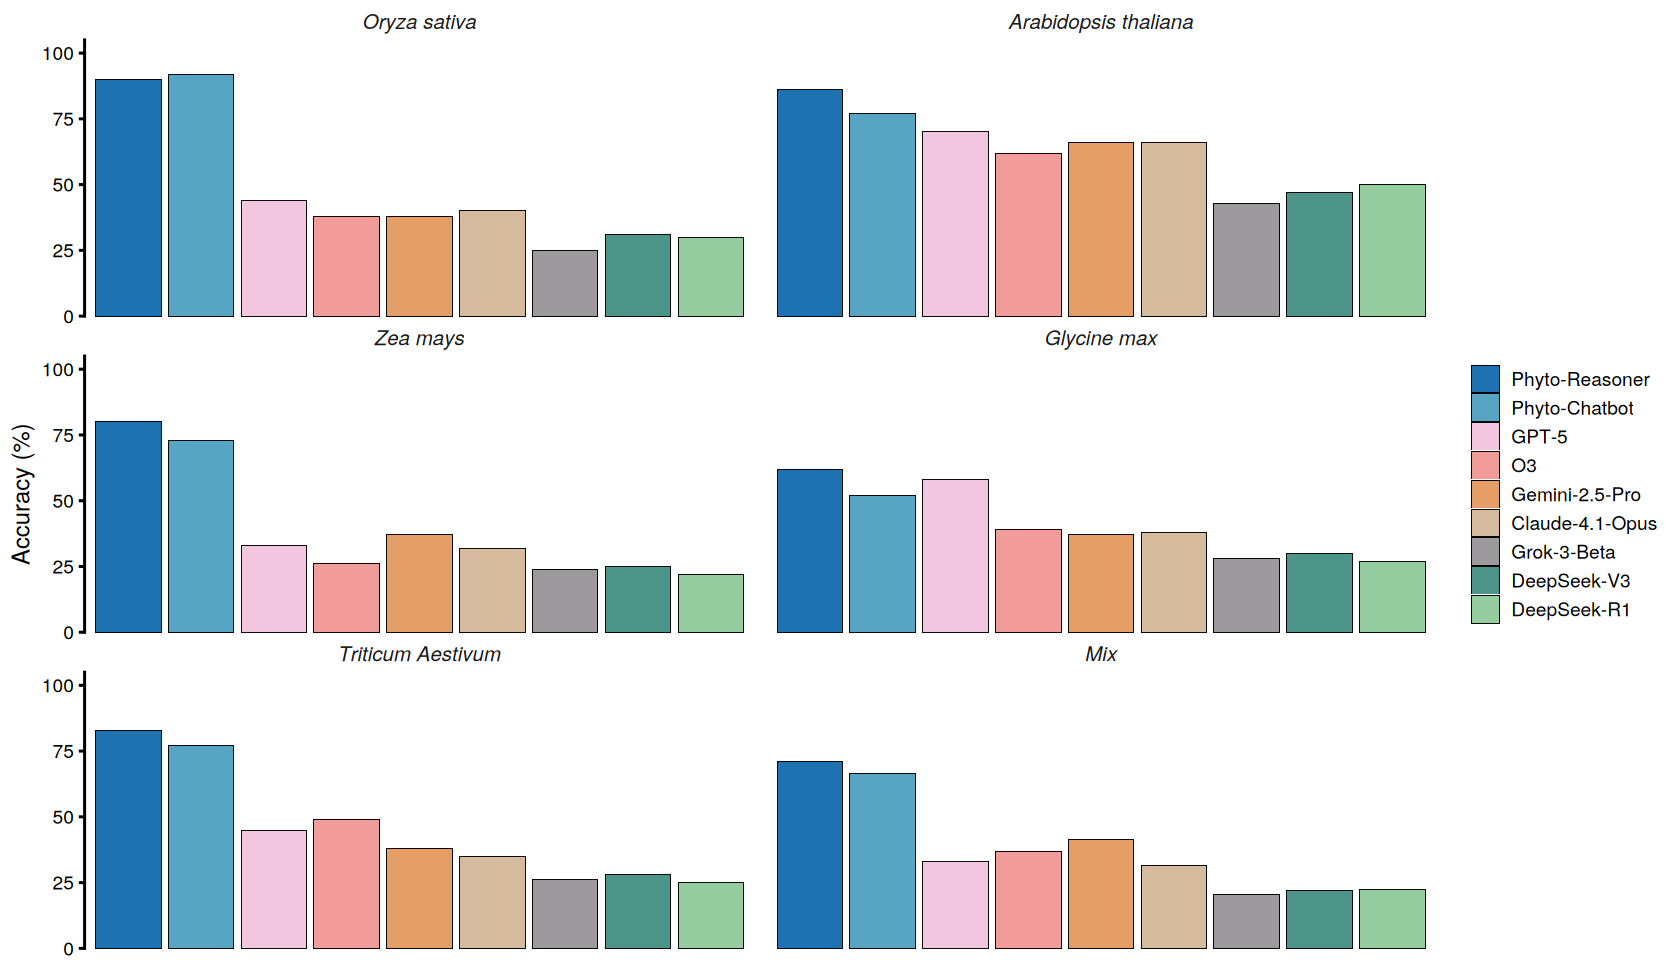

In [3]:
library(tidyverse)
library(ggplot2)
library(scales)

# 1. 内嵌 Figure 1 对应的数据框
df_fig1 <- tibble(
  model = c(
    "Phyto-Chatbot", "Phyto-Reasoner", "Claude-4.1-Opus", 
    "DeepSeek-R1", "DeepSeek-V3", "GPT-5", "Gemini-2.5-Pro", "Grok-3-Beta", "O3"
  ),
  Arabidopsis.thaliana = c(0.77, 0.86, 0.66, 0.50, 0.47, 0.70, 0.66, 0.43, 0.62),
  Oryza.sativa         = c(0.92, 0.90, 0.40, 0.30, 0.31, 0.44, 0.38, 0.25, 0.38),
  Zea.mays             = c(0.73, 0.80, 0.32, 0.22, 0.25, 0.33, 0.37, 0.24, 0.26),
  Glycine.max          = c(0.52, 0.62, 0.38, 0.27, 0.30, 0.58, 0.37, 0.28, 0.39),
  Triticum.Aestivum    = c(0.77, 0.83, 0.35, 0.25, 0.28, 0.45, 0.38, 0.26, 0.49),
  Mix                  = c(0.665, 0.710, 0.315, 0.225, 0.220, 0.330, 0.415, 0.205, 0.370)
)

# 2. 定义配色与排序
color_map_fig1 <- c(
  "Phyto-Reasoner" = "#1e72b2",
  "Phyto-Chatbot"  = "#58A4C3",
  "GPT-5"                            = "#F2C6DE",
  "O3"                               = "#F29C9A",
  "Gemini-2.5-Pro"                   = "#E59E65",
  "Claude-4.1-Opus"                  = "#D6BA9E",
  "Grok-3-Beta"                      = "#9C9A9C",
  "DeepSeek-V3"                      = "#4D9489",
  "DeepSeek-R1"                      = "#96CDA0"
)

order_fig1 <- c(
  "Phyto-Reasoner", "Phyto-Chatbot", "GPT-5", "O3",
  "Gemini-2.5-Pro", "Claude-4.1-Opus", "Grok-3-Beta", "DeepSeek-V3", "DeepSeek-R1"
)

sp_order <- c("Oryza sativa", "Arabidopsis thaliana", "Zea mays",
              "Glycine max", "Triticum Aestivum", "Mix")

# 3. 数据转换：宽表转长表
df_long_fig1 <- df_fig1 %>%
  pivot_longer(
    cols = -model,
    names_to = "type",
    values_to = "TRUE_Ratio"
  ) %>%
  mutate(type = str_replace(type, "\\.", " ")) %>%
  mutate(
    model = factor(model, levels = intersect(order_fig1, unique(model))),
    type  = factor(type, levels = sp_order)
  )

# 4. 执行绘图并设置 Notebook 中显示的尺寸
options(repr.plot.width = 14, repr.plot.height = 8)

p1 <- ggplot(df_long_fig1, aes(x = model, y = TRUE_Ratio, fill = model)) +
  geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.2) +
  facet_wrap(~type, scales = "free_x", ncol = 2) +
  labs(x = NULL, y = "Accuracy (%)") +
  theme_classic(base_size = 14) +
  scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)),
                     breaks = seq(0, 1, 0.25), 
                     labels = seq(0, 100, 25)) +
  theme(
    axis.text.x = element_blank(),  
    axis.ticks.x = element_blank(), 
    axis.line.x = element_blank(),  
    panel.background = element_rect(fill = "white", color = NA),
    plot.background  = element_rect(fill = "white", color = NA),
    strip.text = element_text(size = 12, face = "italic", margin = margin(b = 5)), 
    strip.background = element_blank(), 
    legend.position = "right",      
    legend.title = element_blank()  
  ) +
  scale_fill_manual(values = color_map_fig1)

# 直接打印显示
p1

## Extended Data Fig. 6b

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Ignoring unknown labels:
• size : "12"
Warning message:
“No shared levels found between `names(values)` of the manual scale an

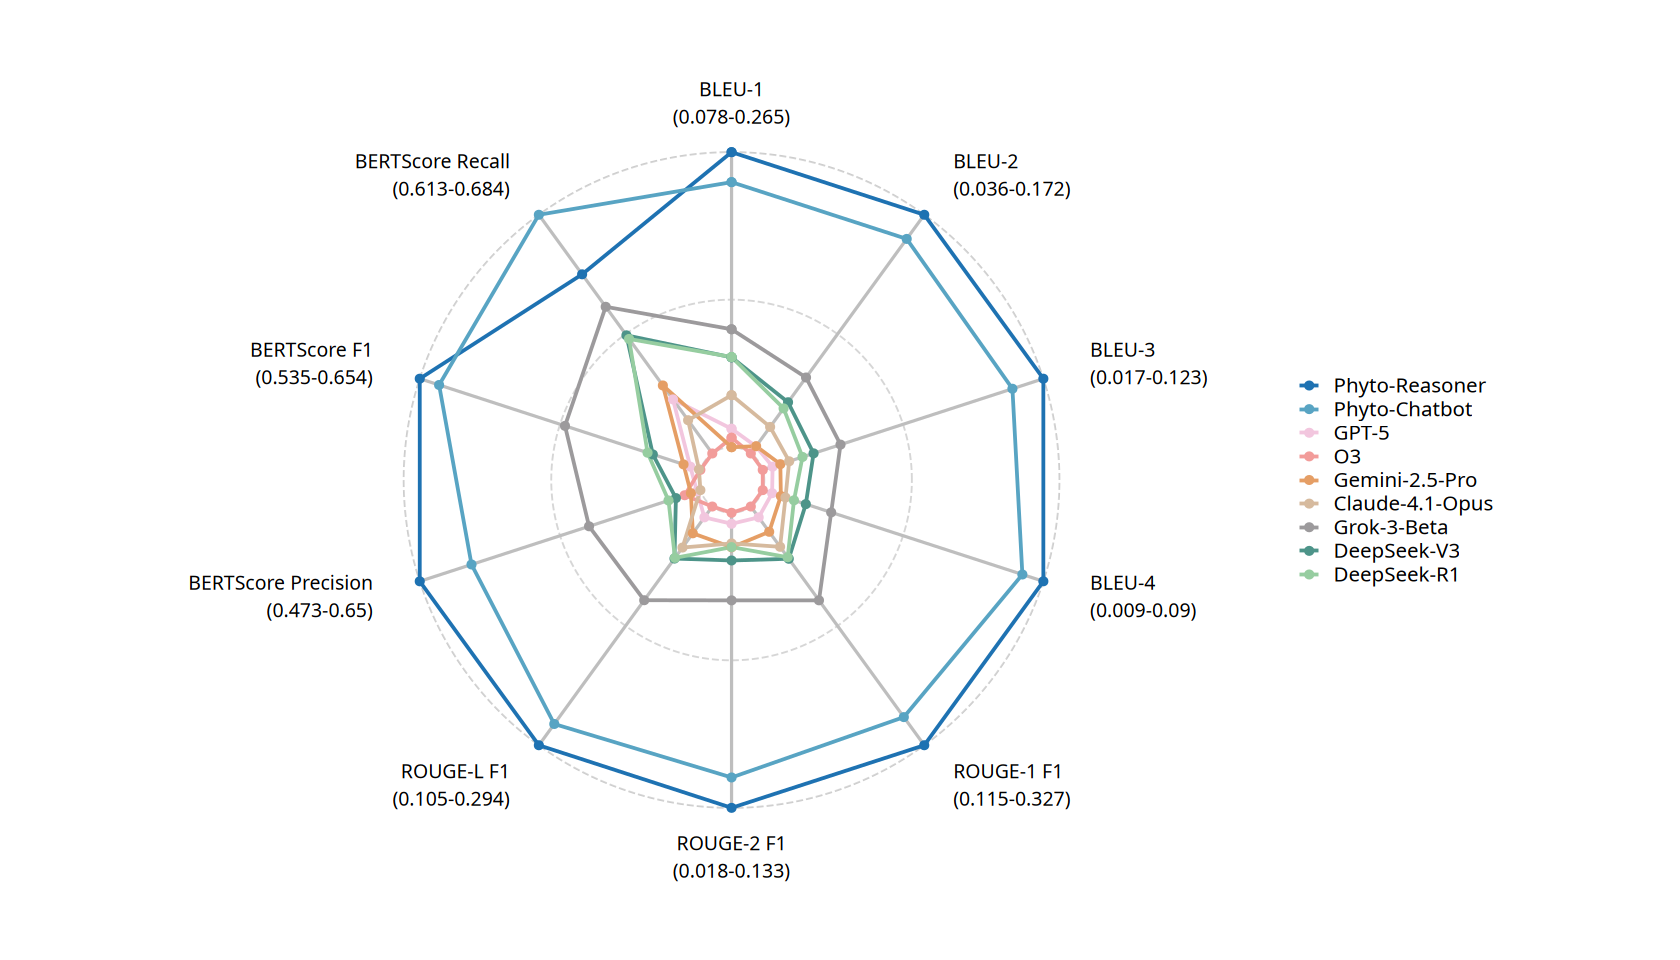

In [1]:
library(tidyverse)
library(ggradar)
library(scales)

# 1. 内嵌 Figure 1 对应的数据框
df_fig1 <- tibble(
  model_name = c(
    "Phyto-Chatbot", "Phyto-Reasoner",
    "DeepSeek-V3", "DeepSeek-R1", "Gemini-2.5-Pro", "GPT-5", "Claude-4.1-Opus", "Grok-3-Beta", "O3"
  ),
  `BLEU-1`              = c(0.24585286, 0.26488576, 0.13461811, 0.13480340, 0.07755058, 0.08925545, 0.11059585, 0.15243157, 0.08357192),
  `BLEU-2`              = c(0.15834360, 0.17205927, 0.06557457, 0.06208644, 0.04061345, 0.04051565, 0.05155267, 0.07963261, 0.03646976),
  `BLEU-3`              = c(0.11160696, 0.12332443, 0.03627798, 0.03208109, 0.02368340, 0.02074213, 0.02703146, 0.04647873, 0.01701432),
  `BLEU-4`              = c(0.084018993, 0.090108939, 0.021148288, 0.017716772, 0.013907711, 0.011369438, 0.015248060, 0.028513310, 0.008644131),
  `ROUGE-1 F1`          = c(0.3016211, 0.3265624, 0.1611939, 0.1598401, 0.1372603, 0.1244401, 0.1505795, 0.1980527, 0.1148472),
  `ROUGE-2 F1`          = c(0.12092842, 0.13274300, 0.03652735, 0.03132091, 0.03139852, 0.02225171, 0.02989348, 0.05204595, 0.01797733),
  `ROUGE-L F1`          = c(0.2775920, 0.2944282, 0.1464192, 0.1458680, 0.1263942, 0.1137432, 0.1376759, 0.1794507, 0.1051508),
  `BERTScore Precision` = c(0.6174101, 0.6500484, 0.4885246, 0.4931896, 0.4790636, 0.4752300, 0.4730968, 0.5432912, 0.4830062),
  `BERTScore F1`        = c(0.6454374, 0.6535978, 0.5552648, 0.5574876, 0.5423157, 0.5394681, 0.5357909, 0.5923261, 0.5352099),
  `BERTScore Recall`    = c(0.6843009, 0.6664104, 0.6480876, 0.6469985, 0.6330256, 0.6288387, 0.6225900, 0.6566591, 0.6125891)
)

# 2. 定义配色与排序
color_map_fig1 <- c(
  "Phyto-Reasoner" = "#1e72b2",
  "Phyto-Chatbot"  = "#58A4C3",
  "GPT-5"                            = "#F2C6DE",
  "O3"                               = "#F29C9A",
  "Gemini-2.5-Pro"                   = "#E59E65",
  "Claude-4.1-Opus"                  = "#D6BA9E",
  "Grok-3-Beta"                      = "#9C9A9C",
  "DeepSeek-V3"                      = "#4D9489",
  "DeepSeek-R1"                      = "#96CDA0"
)

order_fig1 <- c(
  "Phyto-Reasoner", "Phyto-Chatbot", "GPT-5", "O3",
  "Gemini-2.5-Pro", "Claude-4.1-Opus", "Grok-3-Beta", "DeepSeek-V3", "DeepSeek-R1"
)

# 3. 准备雷达图数据与极值计算
plot_data <- df_fig1 %>% rename(group = model_name)

range_labels <- plot_data %>%
  select(-group) %>%
  summarise(across(everything(), list(min = ~min(.), max = ~max(.)))) %>%
  pivot_longer(everything(), names_to = c("metric", ".value"), names_sep = "_") %>%
  mutate(label = paste0(metric, "\n(", round(min, 3), "-", round(max, 3), ")"))

metric_names <- colnames(plot_data)[-1]
new_names <- setNames(range_labels$label, range_labels$metric)
colnames(plot_data)[-1] <- new_names[metric_names]

# Min-Max 归一化并锁定因子的顺位
plot_data_norm <- plot_data %>%
  mutate(across(-group, ~ rescale(.))) %>%
  mutate(group = factor(group, levels = intersect(order_fig1, unique(group)))) %>%
  arrange(group)

group_levels <- levels(plot_data_norm$group)
colors_sub <- color_map_fig1[group_levels]

# 4. 执行绘图并调大 Notebook 渲染尺寸
options(repr.plot.width = 14, repr.plot.height = 8)

p1 <- ggradar(
  plot_data_norm,
  group.line.width = 0.8,
  group.point.size = 1.5,
  grid.line.width = 0.4,
  grid.min = 0, grid.mid = 0.5, grid.max = 1,
  background.circle.colour = "white",
  gridline.min.colour = "gray80", gridline.mid.colour = "gray80", gridline.max.colour = "gray80",
  axis.label.size = 4, legend.text.size = 12,            
  values.radar = c("", "", "")      
)

p1$coordinates$clip <- "off"

p1 <- p1 +
  scale_color_manual(values = setNames(colors_sub, group_levels)) +
  scale_fill_manual(values = setNames(colors_sub, group_levels)) +
  theme(
    panel.background = element_rect(fill = "white", colour = NA),
    plot.background = element_rect(fill = "white", colour = NA),
    panel.border = element_blank(),
    axis.line = element_blank(),
    axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.title = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 12), legend.title = element_blank(),
    legend.key.size = unit(0.5, "cm"), legend.key.height = unit(0.5, "cm"), legend.key.width = unit(0.5, "cm"),
    legend.margin = margin(0, 0, 0, 0), legend.box.margin = margin(0, 0, 0, 0),
    legend.spacing.y = unit(0.2, "cm"), legend.direction = "vertical",
    plot.margin = margin(1, 3, 1, 3, "cm")
  )

# 打印图像
p1